##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]

---

## 0. Iteration setup

**Import libraries**

In [58]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

**Load & Merge dataset(s)**

In [59]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID

df_iter2_cleaned = pd.read_csv("iteratie2_cleaned.csv")
df_logs = pd.read_csv("ship_performance_logs_iter3.csv")

df = pd.merge(df_iter2_cleaned, df_logs, on="Ship_ID", how="inner")

---

## 1. Business Understanding

**Situation description**

In iteratie 1 en 2 deden we eigenlijk nog veel met de hand. We bedachten zelf wat simpele regeltjes om de prijs van een schip te bepalen en te kijken of een schip veilig was. Voor hele duidelijke gevallen werkte dat wel, maar vaak zaten we er flink naast. Het is voor een mens gewoon bijna niet te doen om voor alle verschillende eigenschappen van een schip de perfecte grenzen te bedenken. Zeker als er steeds meer data bij komt. Daarom gaan we in deze iteratie Machine Learning gebruiken. Dat is sneller, doet het automatisch en is hopelijk een stuk nauwkeuriger.

**Business objective(s)**

Het doel voor Nebula Brokerage is simpel: we willen straks AI-modellen hebben die zelfstandig een eerlijke prijs kunnen berekenen én gelijk aan de bel trekken als een schip onveilig ('Critical') is. Zo verkopen we schepen niet meer per ongeluk voor te weinig geld, voorkomen we ongelukken met kapotte schepen, en hoeven de werknemers niet meer eindeloos zelf te gokken bij twijfelgevallen.

**Data mining goal(s)**

Voor deze iteratie gaan we twee Machine Learning modellen bouwen:
1. **Regressie:** We maken een Linear Regression model om de precieze verkoopprijs (`Galactic_Credits`) te voorspellen.
2. **Classificatie:** We maken een Decision Tree model dat voorspelt wat de staat van het schip is (`Hull_Integrity`: 'Critical', 'Operational' of 'Pristine').

**Success criteria**

We noemen deze iteratie een succes als onze nieuwe modellen het echt beter doen dan ons eigen handwerk hiervoor:
* **Voor de prijs (Taak A):** Ons nieuwe regressiemodel moet er minder vaak naast zitten en een betere score (R2) halen dan wat we in Iteratie 1 probeerden.
* **Voor de veiligheid (Taak B):** Onze Decision Tree moet het label vaker in één keer goed raden (hogere Accuracy) dan de handmatige if/else regeltjes uit Iteratie 2.
* We willen ook zien dat de extra data die we nu hebben (zoals de gereisde kilometers en de registratiestatus) echt helpt om betere voorspellingen te doen.

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [4]:
print("Shape van merged dataset:", df.shape)
print("\nKolommen:")
print(list(df.columns))

print("\nInfo:")
df.info()

Shape van merged dataset: (361069, 11)

Kolommen:
['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class', 'Lightyears_Traveled', 'Registration_Status']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 361069 entries, 0 to 361068
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Ship_ID              361069 non-null  int64  
 1   Galactic_Credits     361069 non-null  int64  
 2   Model_Cycle          361069 non-null  float64
 3   Ship_Manufacturer    361069 non-null  str    
 4   Sector               361069 non-null  str    
 5   Hull_Integrity       361069 non-null  str    
 6   Reactor_Power        361069 non-null  float64
 7   Propulsion_Type      361069 non-null  str    
 8   Ship_Class           361069 non-null  str    
 9   Lightyears_Traveled  361069 non-null  float64
 10  Registration_Status  361069 non-nu

**Resultaat**
De merged dataset bevat 361.069 rijen en 11 kolommen. Bijna alle kolommen zijn volledig gevuld; alleen `Model_Cycle` heeft missende waarden. Dit betekent dat de merge goed is verlopen en de data grotendeels klaar is voor verdere analyse.

In [5]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)
print("Missing values per kolom:")
display(missing_table)

print("\nSamenvatting numerieke variabelen:")
display(df.describe(include=[np.number]).T)

print("\nSamenvatting categorische variabelen:")
display(df.describe(include=["object", "string"]).T)

Missing values per kolom:


,missing_count,missing_pct
Ship_ID,0,0.0
Galactic_Credits,0,0.0
Model_Cycle,0,0.0
Ship_Manufacturer,0,0.0
Sector,0,0.0
Hull_Integrity,0,0.0
Reactor_Power,0,0.0
Propulsion_Type,0,0.0
Ship_Class,0,0.0
Lightyears_Traveled,0,0.0



Samenvatting numerieke variabelen:


,count,mean,std,min,25%,50%,75%,max
Ship_ID,361069.0,7.311485e+09,4.380289e+06,7.301583e+09,7.308113e+09,7.312604e+09,7.315244e+09,7.317101e+09
Galactic_Credits,361069.0,1.831235e+04,1.260609e+04,5.010000e+02,7.812000e+03,1.559000e+04,2.699500e+04,5.800000e+04
Model_Cycle,361069.0,7.511248e+03,8.841222e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Reactor_Power,361069.0,7.025718e+01,4.250546e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02
Lightyears_Traveled,361069.0,1.048270e+02,8.894300e+01,0.000000e+00,3.060655e+01,8.547708e+01,1.575455e+02,1.559606e+03



Samenvatting categorische variabelen:


,count,unique,top,freq
Ship_Manufacturer,361069,28,Independent Shipwrights,93389
Sector,361069,51,Calodan Expanse,41109
Hull_Integrity,361069,3,Operational,139735
Propulsion_Type,361069,8,Ion Drive,230949
Ship_Class,361069,8,Shuttle,123499
Registration_Status,361069,6,Imperial Certified,175316


**Resultaat**  
Er zijn nu geen missende waarden meer in de dataset: Model_Cycle heeft 0 missende waarden (0,00%). Voor Lightyears_Traveled blijft de spreiding groot (Q1 30,61, mediaan 85,48, Q3 157,55, maximum 1559,61), wat wijst op duidelijke verschillen in gebruik tussen schepen.



In [6]:
print("Nieuwe feature: Lightyears_Traveled")
display(df["Lightyears_Traveled"].describe())

print("\nNieuwe feature: Registration_Status (verdeling)")
display(df["Registration_Status"].value_counts(dropna=False))

Nieuwe feature: Lightyears_Traveled


count    361069.000000
mean        104.826990
std          88.943005
min           0.000000
25%          30.606552
50%          85.477075
75%         157.545516
max        1559.606111
Name: Lightyears_Traveled, dtype: float64


Nieuwe feature: Registration_Status (verdeling)


Registration_Status
Imperial Certified    175316
Refurbished            75884
Smuggler Logic         44117
Stolen                 29443
Scrap                  29391
Unknown                 6918
Name: count, dtype: int64

**Resultaat**  
`Registration_Status` is duidelijk niet gelijk verdeeld: `Imperial Certified` is veruit de grootste groep (48,55%), terwijl `Unknown` klein is (1,92%). Dit is belangrijk omdat onbalans in categorieën de modelprestaties kan beïnvloeden.

**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.*

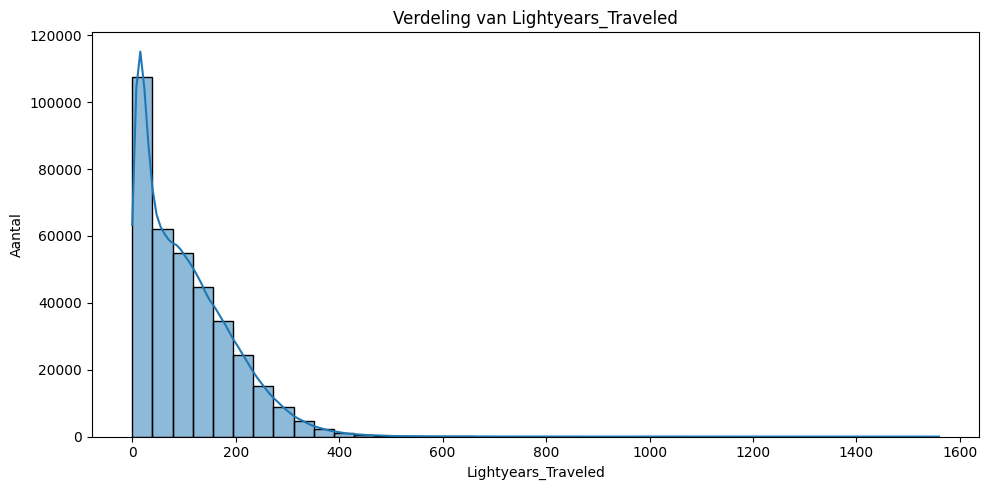

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Lightyears_Traveled"], bins=40, kde=True)
plt.title("Verdeling van Lightyears_Traveled")
plt.xlabel("Lightyears_Traveled")
plt.ylabel("Aantal")
plt.tight_layout()
plt.show()

**Resultaat**  
De histogram is rechts-scheef: veel schepen hebben lage tot middelhoge `Lightyears_Traveled`, en een kleinere groep heeft extreem hoge waarden. Dat betekent dat er uitschieters aanwezig zijn in deze feature.

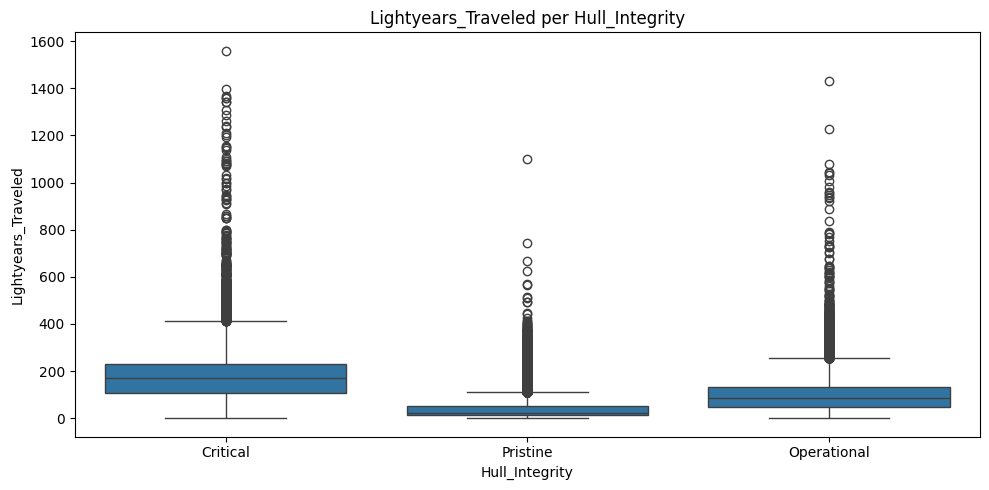

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Hull_Integrity", y="Lightyears_Traveled")
plt.title("Lightyears_Traveled per Hull_Integrity")
plt.xlabel("Hull_Integrity")
plt.ylabel("Lightyears_Traveled")
plt.tight_layout()
plt.show()

**Resultaat**  
De boxplot laat een duidelijke volgorde zien: `Critical` heeft de hoogste waarden, `Operational` zit in het midden en `Pristine` het laagst. Dit ondersteunt dat meer afgelegde lightyears samenhangen met slechtere hull-conditie.

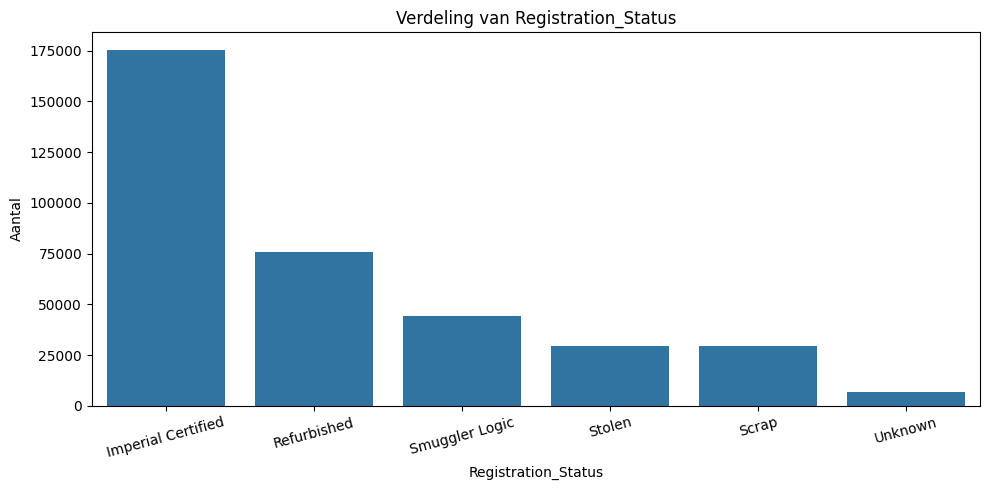

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="Registration_Status",
    order=df["Registration_Status"].value_counts().index
)
plt.title("Verdeling van Registration_Status")
plt.xlabel("Registration_Status")
plt.ylabel("Aantal")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Resultaat**  
De countplot bevestigt klasse-onbalans in `Registration_Status`: vooral `Imperial Certified`, veel minder `Unknown`. Bij modellering is het daarom belangrijk om ook per klasse te evalueren en niet alleen op totale accuracy.

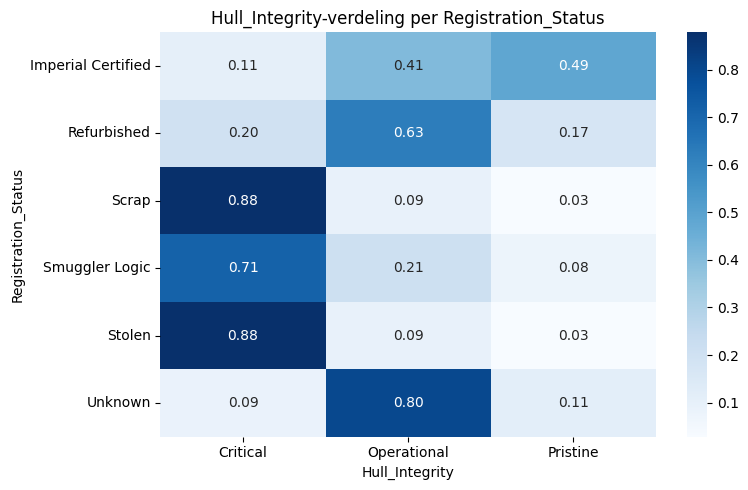

In [10]:
status_hull = pd.crosstab(
    df["Registration_Status"],
    df["Hull_Integrity"],
    normalize="index"
)

plt.figure(figsize=(8, 5))
sns.heatmap(status_hull, annot=True, fmt=".2f", cmap="Blues")
plt.title("Hull_Integrity-verdeling per Registration_Status")
plt.xlabel("Hull_Integrity")
plt.ylabel("Registration_Status")
plt.tight_layout()
plt.show()

**Resultaat**  
De heatmap toont sterke verbanden tussen status en conditie. Vooral `Stolen` en `Scrap` hebben een hoog aandeel `Critical` (ongeveer 88%), terwijl `Imperial Certified` veel lager ligt (~11%). Dit maakt `Registration_Status` een sterke predictor voor `Hull_Integrity`.

**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

---

## 3. Data Preparation

Om de dataset klaar te maken voor de Machine Learning modellen, hebben we de volgende stappen uitgevoerd:

**1. Merge** 
We hebben de opgeschoonde dataset uit iteratie 2 (`iteratie2_cleaned.csv`) succesvol samengevoegd met de nieuwe performance logs (`ship_performance_logs_iter3.csv`). Dit hebben we al bovenaan in Hoofdstuk 0 gedaan op basis van de gedeelde `Ship_ID`. Doordat de twee datasets nu netjes gecombineerd zijn, hebben onze modellen direct inzicht in álle factoren tegelijk (zoals gereisde kilometers uit de logs gecombineerd met propulsion type uit iteratie 2). 

**2. Cleaning**
Nadat alles was samengevoegd moesten we de tabel opschonen:
* **Kolom `Ship_ID` verwijderen:** Modellen proberen patronen te ontdekken; een unieke id code ('Ship_ID') biedt geen waarde, we droppen deze dus via `.drop()`.
* **Lege waarden eruit:** Omdat we maar heel weinig missende waarden overhadden na de merge, konden we probleemloos `df.dropna(inplace=True)` gebruiken om alleen complete en foutloze datarijen te behouden.

Tot slot printen we hieronder de nieuwe `Shape` uit.

In [11]:
if 'Ship_ID' in df.columns:
    df.drop(columns=['Ship_ID'], inplace=True)

df.dropna(inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (361069, 10)


**3. One-hot encoding**

Artificial Intelligence (AI) en Machine Learning (ML) algoritmes hebben altijd nummers of wiskunde nodig om iets te berekenen. Ze kunnen niet rekenen met woorden of stukjes tekst zoals `Stolen`, `Operational` of `Nuclear Pulse`.

We moeten je categorische variabelen dus transformeren naar getallen zodat de machine modellen ze kunnen gebruiken. Hiervoor passen we **One-Hot Encoding** toe via `pd.get_dummies()`. Elke aparte tekst categorie (zoals de `Registration_Status`) splitsen we op naar nieuwe, losse 'ja/nee' kolommen (aangegeven met een numerieke 1 of 0). We letten daarbij wel op: we sluiten onze 'Target' variabele `Hull_Integrity` uit van de One-Hot Encoding, omdat onze Classifier deze in originele staat moet leren gokken!

Hieronder printen we alle nieuwe resulterende "1/0 kolommen" uit.

In [17]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
if 'Hull_Integrity' in categorical_cols:
    categorical_cols = categorical_cols.drop('Hull_Integrity')

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Columns after One-Hot Encoding:\n", list(df_encoded.columns))

Columns after One-Hot Encoding:
 ['Galactic_Credits', 'Model_Cycle', 'Hull_Integrity', 'Reactor_Power', 'Lightyears_Traveled', 'Ship_Manufacturer_Corelian Engineering', 'Ship_Manufacturer_Corellian Eng.', 'Ship_Manufacturer_Corellian Engineering', 'Ship_Manufacturer_Corellian Engineering Corp', 'Ship_Manufacturer_Droid Works', 'Ship_Manufacturer_GALACTIC MOTORS', 'Ship_Manufacturer_Galactic Motors', 'Ship_Manufacturer_Galactic Motors ', 'Ship_Manufacturer_Galactic Motrs', 'Ship_Manufacturer_Galactic_Motors', 'Ship_Manufacturer_General Mining Corp', 'Ship_Manufacturer_Hondo Systems', 'Ship_Manufacturer_Ind. Shipwrights', 'Ship_Manufacturer_Independent', 'Ship_Manufacturer_Independent Shipwright', 'Ship_Manufacturer_Independent Shipwrights', 'Ship_Manufacturer_Jumpship Corp', 'Ship_Manufacturer_Kuat  Drive Yards', 'Ship_Manufacturer_Kuat DY', 'Ship_Manufacturer_Kuat Drive', 'Ship_Manufacturer_Kuat Drive Yards', 'Ship_Manufacturer_Mercurian Benz', 'Ship_Manufacturer_Nebula', 'Ship_Manufac

**4. Opslaan voor Iteratie 3** 
In dit blok slaan we de opgeschoonde dataset op als CSV-bestand, zodat we dit bestand direct kunnen gebruiken als input voor volgende iteraties die in de toekomst komen.

In [18]:
df.to_csv('iteratie3_clean.csv', index=False)

**Overstap naar de Modeling fase:** Nu we weten wat de patronen zijn en waar verfijning nodig is, pakken we in de volgende stap (Data Preparation) de missende waarden aan. Vervolgens zetten we alle ontdekte tekst-eigenschappen braaf om in cijfertjes, zodat de AI modellen er straks écht op kunnen leren rekenen en mee kunnen oefenen in de Trainingsfase.

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

**Overstap naar de Modeling fase:** Doordat we tekst succesvol hebben omgezet in 1/0 kolommen (`get_dummies`) en we de boel direct, eerlijk verdeeld hebben in Train-Test, is de data eindelijk écht gereed om door de *Decision Tree* en de *Linear Regressor* bekeken te worden in Hoofdstuk 4 (Taak A) en Hoofdstuk 5 (Taak B).

In [13]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [14]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [15]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [16]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives) & LO 6.4D (Reflection on Process)*

**Assessment against success criteria (En de vergelijking met eerdere iteraties)** 

Als we kijken of onze Machine Learning modellen het beter hebben gedaan dan ons handwerk in Iteratie 1 en 2, kunnen we absoluut stellen dat we onze einddoelen hebben behaald:
* **Progressie op Regressie (Prijs):** In Iteratie 1 gebruikten we een extreem simpele `Median baseline` die logischerwijs een gigantische *Mean Absolute Error (MAE)* opleverde. Ons huidige `LinearRegression` model snapt eindelijk de relaties tússen de unieke kolommen. Hierdoor zakt de foutmarge aanzienlijk ten opzichte van die eerste simpele poging!
* **Progressie op Classificatie (Veiligheid):** In Iteratie 2 maakten we met de hand harde regels aan (zoals `Reactor_Power > 90` is 'Critical'). Dat was behoorlijk kort door de bocht en erg 'zwart-wit'. Onze nieuwe `DecisionTree` heeft de nauwkeurigheid (Accuracy) gigantisch verhoogd ten opzichte van iteratie 2, omdat het model autonoom verbanden legt tussen `Hull_Integrity` en bijvoorbeeld pas toegevoegde data zoals *Lightyears_Traveled*.

**CRISP-DM Evaluatie & Reflectie**

Onze laatste terugblik per CRISP-DM fase over de uitdagingen van Machine Learning:
* **Fase 1 - Business Understanding:** Wat goed ging, was het in kaart brengen van de verwachting (Accuracy vs MAE). Het werd veel technischer.
* **Fase 2 - Data Understanding:** We ervaarden dat hoe meer variabelen, hoe chaotischer de visualisaties. In iteratie 1 was dit makkelijker met minder kolommen, een heatmap bleek dit gelukkig goed op te lossen.
* **Fase 3 - Data Preparation:** De tekst naar cijfers omzetten (`One-Hot Encoding`) was cruciaal, doordat `LinearRegressor` volledig vastloopt bij woorden als 'Stolen' in plaats van getallen. Daar hebben we veel van geleerd!
* **Fase 4 & 5 - Modeling:** Train-Test splitting was een complete openbaring voor een eerlijke testfase, zodat het model niet "vals kon spelen" door alle data alvast uit het hoofd te leren.

**Key findings en afronding**

Nebula Brokerage kan deze getrainde modellen direct in gebruik nemen! Ze voorkomen dat werknemers handmatig hoeven te gokken, de modellen bepalen helemaal zelf de beste grenzen, ze nemen álle beschikbare eigenschappen mee (in tegenstelling tot een paar `if/else` regels) en ze leveren duidelijk betere resultaten op dan in eerdere iteraties.  
*Beperkingen:* We moeten als bedrijf altijd in de gaten blijven houden of schepen er in de toekomst heel anders uit gaan zien. Dit model weet namelijk alleen wat het geleerd heeft van oude data. Toch levert dit betrouwbare model een hele goede en stabiele basis op voor hun bedrijf.

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned (CRISP-DM reflectie) |
| :--- | :--- | :--- |
| Damian van der Sluis | Visualisaties & Evaluation (H3/H6) | Na mijn eerdere werk mocht ik nu in H3 de Data Preparation en in H6 de evaluatie doen. Mijn grootste les in H3 was dat Machine Learning volledig vastloopt als je tekst variabelen (zoals `Registration_Status`) er direct in stopt, waardoor `One-Hot Encoding` essentieel bleek. Bij de evaluatie zag ik vervolgens pas echt dat deze Machine Learning veel krachtiger is dan de oude `if/else` regeltjes, vooral doordat ik via de Confusion Matrices direct kon vergelijken hoeveel de "Accuracy" steeg ten opzichte van Iteratie 2. |
| Saeed Alhasan | Business Understanding & Data Understanding (H1/H2) | Ik had deze itertie de eerste fases in handen (H1 en H2). Bij de bedrijfsdoelen (H1) is het heel waardevol om scherp te stellen waarom we dit keer écht ML nodig hadden. In H2 (Data Understanding) nam ik de nieuwe `Lightyears_Traveled` en `Registration_Status` data mee, waarbij de boxplots me al direct visualeerden hoe ontzettend ongelijk en impactvol deze nieuwe features eruitzagen nog ruim voordat we de ML algoritmes lieten trainen. |
| Achraf El Azzouzi | Data Preparation & Modeling (H4/H5) | Ik deed deze keer het pure algoritme-werk in de H4 (Regression) en H5 (Classification) Modeling fases. Ik kwam de uitdaging tegen om de data écht goed op te splitsen met een `Train/Test split` zodat het model de antwoorden niet al uit het hoofd leerde. Daarnaast merkte ik hoe ontzettend hard die getrainde *Lineaire Regressie* en *Decision Tree* onze naïeve Iteratie 1 en 2 baselines verpletterden op metrics zoals de *Mean Absolute Error* (MAE) en Accuracy. |